# Model Interpretation & Explainable AI (SHAP)
In this step, we will use the **LightGBM** model, which yielded the highest performance (Weighted ROC-AUC) from Step 3, to explain the relationships of factors influencing the Turnover Intention of public-sector employees.

The tool we are using is **SHAP (SHapley Additive exPlanations)** to explain the results at 2 levels:
1. **Global Interpretation:** An overall view of which variables are most important to the model
2. **Local Interpretation:** Individual explanations of why a specific employee is predicted to have high or low risk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
import os
import warnings
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
shap.initjs() # To enable JavaScript plot rendering (for certain plots)

/Users/barabank/Desktop/Folder/UE/Semester 4/Explainable Prediction of Public-Sector Employee Turnover Intention/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Prepare data and train the model again
Because the SHAP TreeExplainer algorithm works best and fastest when reading the Tree structure directly, we need to Train a pure `LGBMClassifier` again.

In [2]:
# 1. Load the preprocessed data
df = pd.read_csv('../data/fevs_processed_for_ml.csv')

# 2. Separate target and aggregate weights
y = df['Turnover_Intention']
weights = df['POSTWT']
X = df.drop(columns=['Turnover_Intention', 'POSTWT'])
X_filled = X.fillna(-1)

# 3. Split data (Train 80%, Test 20%) with the same Seed to remain consistent across all steps
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_filled, y, weights, test_size=0.2, stratify=y, random_state=42
)

print("Train Data Size:", X_train.shape)
print("Test Data Size:", X_test.shape)

Train Data Size: (401579, 111)
Test Data Size: (100395, 111)


In [3]:
# 4. Load the Best Tuned Model from Step 3
# We load the uncalibrated model because SHAP TreeExplainer requires the pure tree structure.
import joblib

model = joblib.load('../models/best_lightgbm_model.pkl')
print("Successfully loaded tuned LightGBM model for SHAP Interpretation.")


Successfully loaded tuned LightGBM model for SHAP Interpretation.


## 2. Global Interpretation with SHAP Summary Plot
We will look at which variables drive the probability of turnover (Turnover Intention = 1) the most. 

*Note: Since calculating SHAP values on hundreds of thousands of records is computationally expensive, we will sample 1,000 rows from the Test data to demonstrate and explain.*

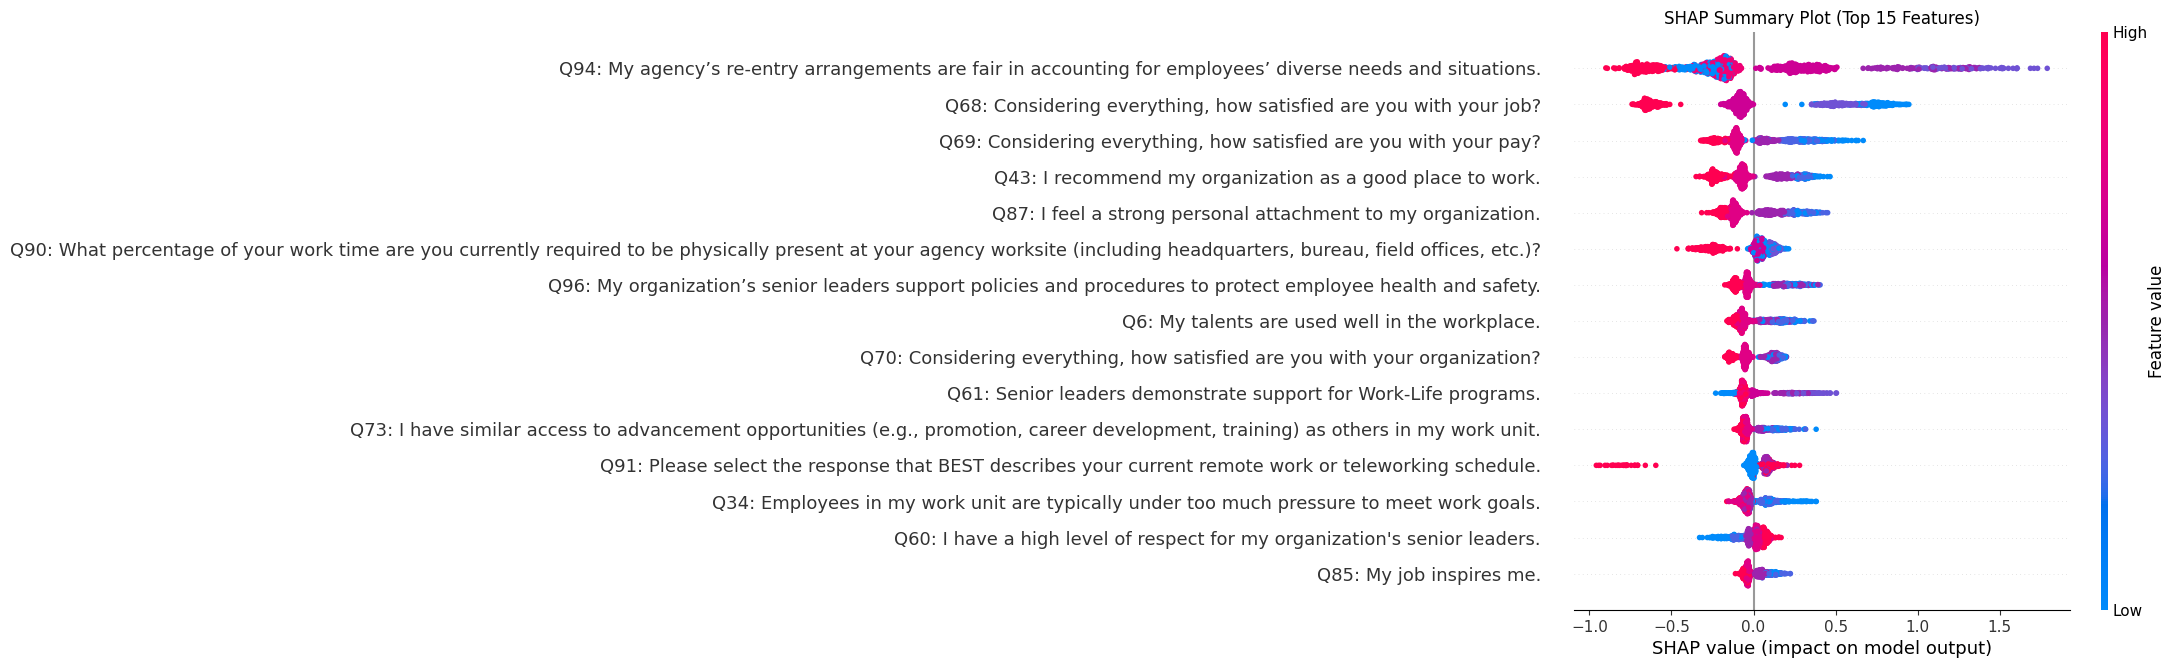

In [4]:
# Sample data to evaluate feature importance
X_test_sample = X_test.sample(n=1000, random_state=42)

# Load Codebook to display questions alongside variable names
codebook = pd.read_csv('../data/codebook_extracted.csv')
codebook_dict = dict(zip(codebook['VARIABLE'], codebook['VARIABLE'] + ": " + codebook['ITEM TEXT']))
feature_labels = [codebook_dict.get(col, col) for col in X_test_sample.columns]

# Create explainer from LightGBM tree structure
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# LightGBM binary classification usually stores results as a list of log odds
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1] # Select Class 1 (Turnover=1)
    expected_value = explainer.expected_value[1]
else:
    shap_vals_to_plot = shap_values
    expected_value = explainer.expected_value

# Draw Summary Plot showing the Top 15 most influential variables
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot (Top 15 Features)")
shap.summary_plot(shap_vals_to_plot, X_test_sample, feature_names=feature_labels, max_display=15, show=False)
plt.show()

### How to read the Summary Plot:
- **Y-axis:** Feature/Variable names (sorted from most impactful at the top to least at the bottom)
- **X-axis (SHAP Value):** Impact on the prediction result 
    - Right side (SHAP > 0): Indicates increased risk of wanting to leave
    - Left side (SHAP < 0): Indicates decreased risk, wanting to stay
- **Dot color (Feature value):** Red indicates high actual value (Raw Answer), blue indicates low value

*(Let us run this and observe how variables like satisfaction with senior leaders or income affect the result)*

## 3. Local Interpretation (Individual Behavior)
Select 2 employee examples to compare: someone with a very high risk of leaving (High Risk) and someone with no risk (Low Risk), to see why the system makes those predictions and why it believes they are different.
A **Waterfall Plot** will help us see the initial expected score and how each factor contributes by "adding" or "subtracting" from this intention.

In [5]:
# Find High Risk vs Low Risk individuals
probs = model.predict_proba(X_test_sample)[:, 1]

high_risk_idx = np.argmax(probs)
low_risk_idx = np.argmin(probs)

print(f"Highest risk employee in the group (Index {high_risk_idx}) has Probability {probs[high_risk_idx]:.4f}")
print(f"Lowest risk employee in the group (Index {low_risk_idx}) has Probability {probs[low_risk_idx]:.4f}")

Highest risk employee in the group (Index 404) has Probability 0.9159
Lowest risk employee in the group (Index 842) has Probability 0.0057



--- Individual Analysis: High-Risk Employee ---


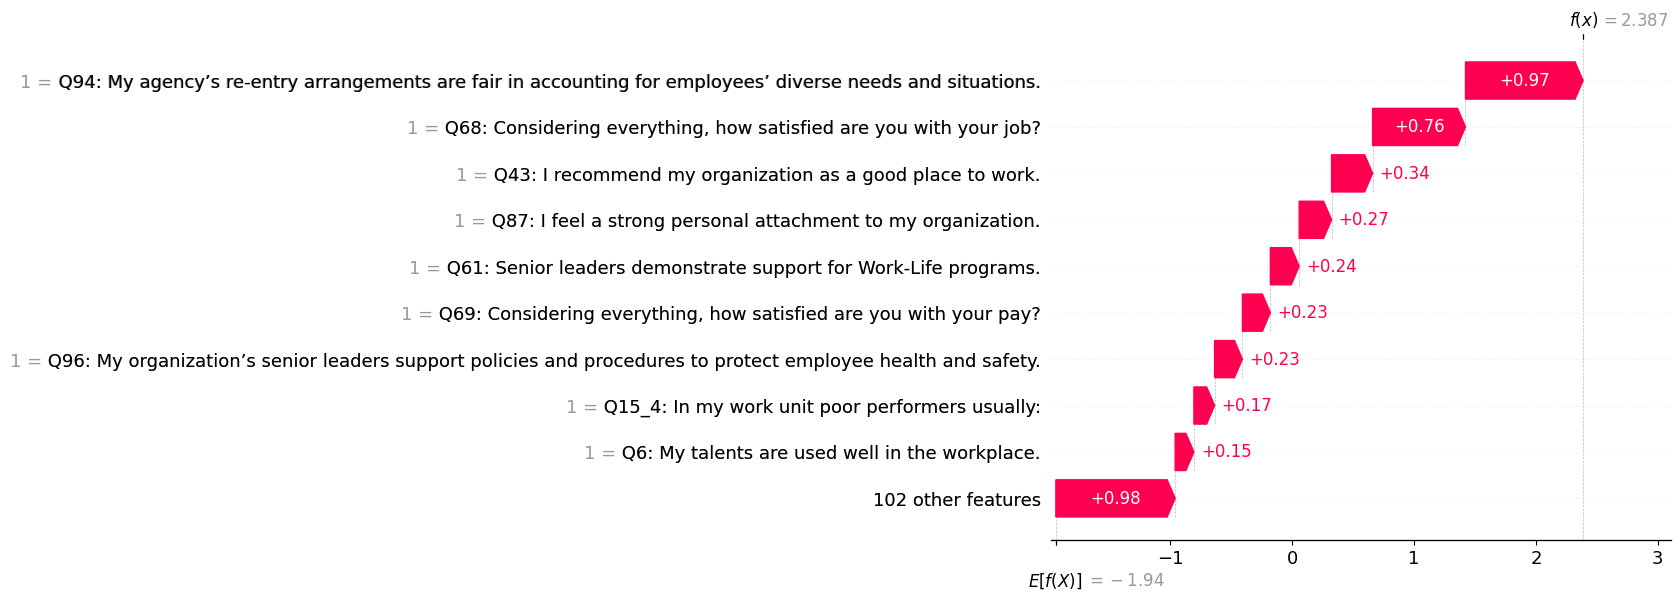

In [6]:
print("\n--- Individual Analysis: High-Risk Employee ---")
# Create object for SHAP explanation to draw waterfall (supports shap version > 0.40)
person_high = shap.Explanation(
    values=shap_vals_to_plot[high_risk_idx],
    base_values=expected_value,
    data=X_test_sample.iloc[high_risk_idx],
    feature_names=feature_labels
)

shap.plots.waterfall(person_high, max_display=10)


--- Individual Analysis: Low-Risk Employee ---


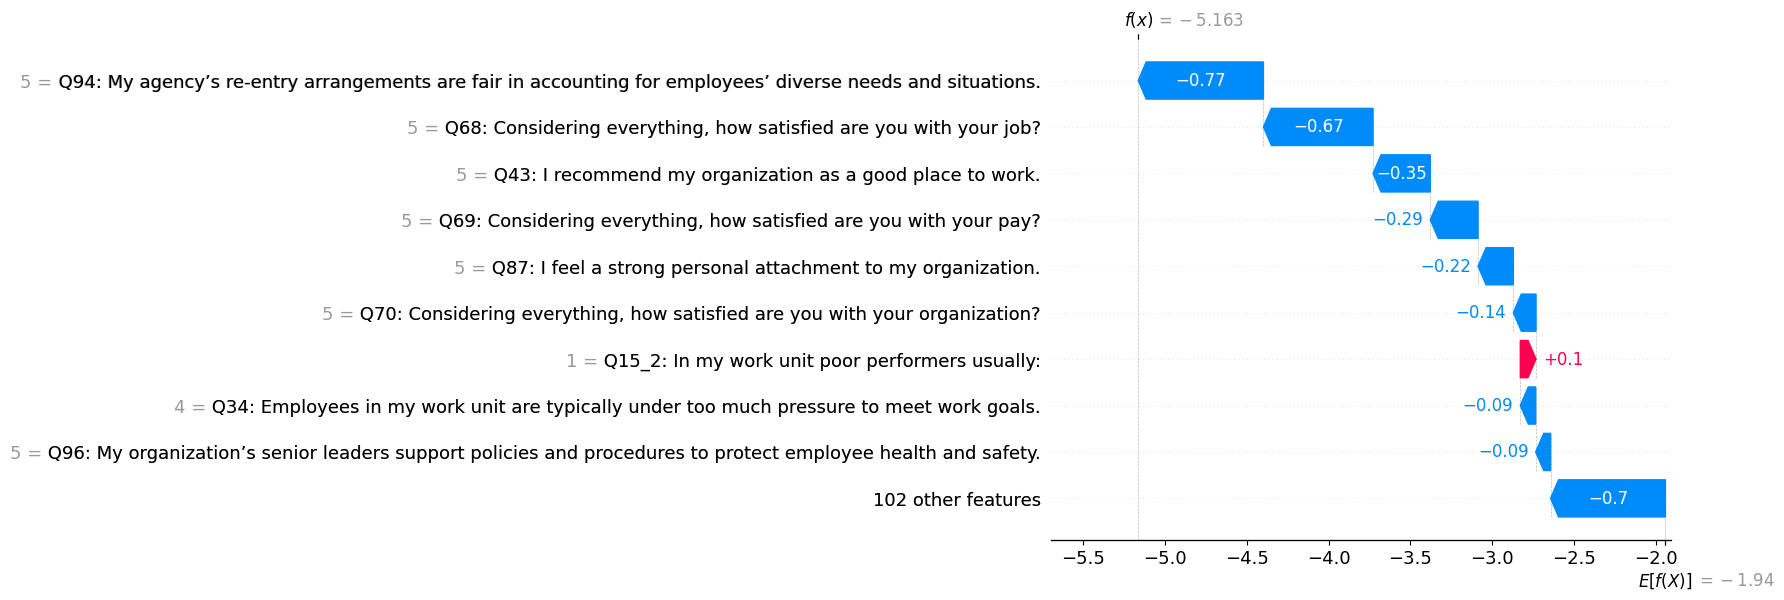

In [7]:
print("\n--- Individual Analysis: Low-Risk Employee ---")
person_low = shap.Explanation(
    values=shap_vals_to_plot[low_risk_idx],
    base_values=expected_value,
    data=X_test_sample.iloc[low_risk_idx],
    feature_names=feature_labels
)

shap.plots.waterfall(person_low, max_display=10)